In [7]:
import glob

import xarray as xr
import numpy as np
import intake
import dask 

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.mpl
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import xesmf as xe

In [8]:
from dask.distributed import Client
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/42915/status,
Dashboard: /proxy/42915/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39273,Workers: 0
Dashboard: /proxy/42915/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46495,Total threads: 1
Dashboard: /proxy/37181/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:45591,


In [9]:
def detrend_1d(y, deg=1):
    x = np.arange(y.size)  
    z = np.polyfit(x, y, deg)  
    trend = np.polyval(z, x) 
    return y - trend + np.mean(y)

def detrend_monthly(da, deg=1):
    return da.groupby('time.month').apply(
        lambda x: xr.apply_ufunc(
            detrend_1d, x,
            input_core_dims=[['time']],
            output_core_dims=[['time']],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float],
            kwargs={'deg': deg}
        )
    )
    
def get_seasonal_means(da, seasons):
    da_season_mean = {}
    for season in seasons:
        if season == 'DJF':
            da_season_tmp = da.where(da['time.season'] == 'DJF')
            da_season = da_season_tmp.rolling(min_periods=3, center=True, time=3).mean()
            da_season_mean[season] = da_season.groupby('time.year').mean(dim='time')
        else:
            da_season = da.where(da['time.season'] == season, drop=True)
            da_season_mean[season] = da_season.groupby('time.year').mean(dim='time')
    return da_season_mean

def convert_units(da):
    # Convert Kelvin to Celsius
    if da.attrs.get('units') == 'K':
        da = da - 273.15
        da.attrs['units'] = '°C' 
    
    # Convert Pascal to hectoPascal
    elif da.attrs.get('units') == 'Pa':
        da = da / 100.
        da.attrs['units'] = 'hPa' 

    # Convert kg m-2 s-1 to mm/day
    elif da.attrs.get('units') == 'kg m-2 s-1':
        da = da*86400.
        da.attrs['units'] = 'mm/day' 
    return da

def area_weighted_mean(da, lat_south, lat_north, lon_left, lon_right):
    """
    Computes area-weighted mean over a specified lat-lon box.

    Parameters:
        da (xr.DataArray): Input data with 'lat' and 'lon' dimensions.
        lat_south (float): Southern latitude boundary.
        lat_north (float): Northern latitude boundary.
        lon_left (float): Western longitude boundary.
        lon_right (float): Eastern longitude boundary.

    Returns:
        xr.DataArray: Area-weighted mean over the specified region.
    """
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = 'weights'
    da_area_mean = da.sel(lat=slice(lat_south,lat_north),lon=slice(lon_left,lon_right)).weighted(weights).mean(('lat','lon'))
    return da_area_mean


def calcMonAnom(da):
    """
    Calculates monthly anomalies by subtracting the monthly climatology.

    Parameters:
        da (xr.DataArray): Input data with 'time' dimension.

    Returns:
        xr.DataArray: Monthly anomalies.
    """
    monclim = da.groupby('time.month').mean('time')
    monanom = da.groupby('time.month') - monclim
    return monanom 

In [10]:
from scipy import signal
import pandas as pd


def lowpass_butterworth_xr(da, cutoff_yrs=13, order=4):
    """
    Apply a Butterworth low-pass filter to monthly xarray data.

    Parameters
    ----------
    da : xr.DataArray
        Input data with a 'time' dimension.
    cutoff_yrs : float
        Cutoff period in years (e.g., 13 for 13-year low-pass).
    order : int
        Order of the Butterworth filter.

    Returns
    -------
    xr.DataArray
        Low-pass filtered data, same shape as input.
    """
    # Convert cutoff to months
    cutoff_period = cutoff_yrs * 12
    dt = 1.0  # months between samples
    nyquist = 0.5  # cycles per month
    cutoff_freq = 1.0 / cutoff_period  # cycles per month
    Wn = cutoff_freq / nyquist  # normalized frequency

    # Design the filter
    b, a = signal.butter(order, Wn, btype='low', analog=False)

    def _filt_1d(x):
        """Helper for applying filter along one time series."""
        # Ignore all-NaN slices
        if np.all(np.isnan(x)):
            return np.full_like(x, np.nan)

        # Fill NaNs with nearest valid value (minimizes filter artifacts)
        x_filled = pd.Series(x).interpolate(limit_direction='both').to_numpy()

        # Apply zero-phase filter
        y = signal.filtfilt(b, a, x_filled, method="gust")

        # Mask NaNs back
        y[np.isnan(x)] = np.nan
        return y

    # Apply filter along the 'time' dimension
    da_lp = xr.apply_ufunc(
        _filt_1d,
        da,
        input_core_dims=[["time"]],
        output_core_dims=[["time"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[da.dtype],
    )

    # Preserve attributes and coordinates
    da_lp = da_lp.assign_coords(time=da.time)
    da_lp.attrs.update(da.attrs)
    da_lp.attrs["filter"] = f"{cutoff_yrs}-year Butterworth low-pass"

    return da_lp


def taper(n,fr=0.1,window='hanning'):
   """
   Window to taper fr/2 on both sides, with 'hanning' (default) or 'blackman' windows

    ---
    Harun Rashid
   """

   if window.lower()=='welch':
      return quadwin(n)

   nfrh = int(n*fr/2)
   t = np.ones(n,dtype=float)
   if window.lower()=='blackman':
      wnf = np.blackman(2*nfrh)
   else:
      wnf = np.hanning(2*nfrh)
   t[0:nfrh] = t[0:nfrh]*wnf[0:nfrh]
   t[-nfrh:] = t[-nfrh:]*wnf[nfrh:]
   return t
  

def smooth(x, window_len=7, window='hanning'):
    """
    Smooth the data in x using convolution with a window of requested
    size and type.

    Parameters
    ----------
    x : array_like(float)
        A flat NumPy array containing the data to smooth
    window_len : scalar(int), optional
        An odd integer giving the length of the window.  Defaults to 7.
    window : string
        A string giving the window type. Possible values are 'flat',
        'hanning', 'hamming', 'bartlett' or 'blackman'

    Returns
    -------
    array_like(float)
        The smoothed values

    Notes
    -----
    Application of the smoothing window at the top and bottom of x is
    done by reflecting x around these points to extend it sufficiently
    in each direction.

    This function is faster than pd.rolling() (2.35 times). Also, this doesn't loose
    data at both ends (because of convolution).

   Harun Rashid
    """
    if len(x) < window_len:
        raise ValueError("Input vector length must be >= window length.")

    if window_len < 3:
        raise ValueError("Window length must be at least 3.")

    if not window_len % 2:  # window_len is even
        window_len += 1
        print("Window length reset to {}".format(window_len))

    windows = {'hanning': np.hanning,
               'hamming': np.hamming,
               'bartlett': np.bartlett,
               'blackman': np.blackman,
               'flat': np.ones  # moving average
               }

    # === Reflect x around x[0] and x[-1] prior to convolution === #
    k = int(window_len / 2)
    xb = x[:k]   # First k elements
    xt = x[-k:]  # Last k elements
    s = np.concatenate((xb[::-1], x, xt[::-1]))

    # === Select window values === #
    if window in windows.keys():
        w = windows[window](window_len)
    else:
        msg = "Unrecognized window type '{}'".format(window)
        print(msg + " Defaulting to hanning")
        w = windows['hanning'](window_len)

    return np.convolve(w / w.sum(), s, mode='valid')

def spectrum(x0, window_len=11, window='hanning'):
#def periodogram(x, window=None, window_len=7):
    r"""
    Computes the periodogram

    .. math::

        I(w) = \frac{1}{n} \Big[ \sum_{t=0}^{n-1} x_t e^{itw} \Big] ^2

    at the Fourier frequences :math:`w_j := \frac{2 \pi j}{n}`,
    :math:`j = 0, \dots, n - 1`, using the fast Fourier transform. Only the
    frequences :math:`w_j` in :math:`[0, \pi]` and corresponding values
    :math:`I(w_j)` are returned. If a window type is given then smoothing
    is performed.

    Parameters
    ----------
    x : 1-d array_like(float)
        A flat NumPy array containing the data to analyse
    window : string
        A string giving the window type. Possible values are 'flat',
        'hanning' (default), 'hamming', 'bartlett' or 'blackman'
    window_len : scalar(int), optional(default=11)
        An odd integer giving the length of the window.  Defaults to 11.

    Returns
    -------
    w : array_like(float)
        Fourier frequences at which spectrum is evaluated
    I_w : array_like(float)
        Values of spectrum at the Fourier frequences

    ---
    Harun Rashid
    """
    n = len(x0)
    #if dtrend in [1,2]:
    #   h_detrended = detrend(x,dtrend)
    #else:
    #   h_detrended = h
    varx0 = x0.var() #variance
    winweights = taper(n,0.1)
    x = x0 * winweights
    I_w = np.abs(np.fft.fft(x))**2 / n
    #w = 2 * np.pi * np.arange(n) / n  # Fourier frequencies
    w = np.arange(n) / n  # Fourier frequencies (I changed to linear freqs)
    w, I_w = w[:int(n/2)+1], I_w[:int(n/2)+1]  # Take only values on [0, pi]
    if window:
        I_w = smooth(I_w, window_len=window_len, window=window)
    spec_vals = 2*I_w*varx0.values/((x.var()).values)       # multiplying by 2 keeps the observed variance
    if isinstance(x,pd.Series):
        return pd.Series(spec_vals,index=w)
    else:
        return w, spec_vals

In [11]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/scratch/{os.environ['PROJECT']}/{os.environ['USER']}/nesp/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json


In [12]:
import warnings
warnings.filterwarnings('ignore')


#datastore_path = "/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json"
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [13]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

    

In [14]:
datastore_filtered = datastore.search(realm="atmos", frequency="1mon")

for col in COLUMNS_WITH_ITERABLES:
    datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

df = available_variables(datastore_filtered)
df.index


Index(['fld_s00i004', 'fld_s00i010', 'fld_s00i012', 'fld_s00i023',
       'fld_s00i024', 'fld_s00i025', 'fld_s00i028', 'fld_s00i029',
       'fld_s00i031', 'fld_s00i032',
       ...
       'rho_level_height', 'sigma_rho', 'sigma_theta', 'sigma_theta_0',
       'sigma_theta_1', 'sigma_theta_2', 'theta_level_height',
       'theta_level_height_0', 'theta_level_height_1', 'theta_level_height_2'],
      dtype='object', name='variable', length=245)

In [15]:
ts_ds = datastore.search(variable="fld_s00i024", frequency="1mon")
    
ts = ts_ds.to_dask(
    xarray_open_kwargs={
        "chunks": "auto",
   },
    xarray_combine_by_coords_kwargs={
        'compat' : 'override',
        'data_vars': 'minimal',
        'coords': 'minimal'
    })
    
pr_ds = datastore.search(variable="fld_s05i216", frequency="1mon")
pr = pr_ds.to_dask(
    xarray_open_kwargs={
        "chunks": "auto",
   },
    xarray_combine_by_coords_kwargs={
        'compat' : 'override',
        'data_vars': 'minimal',
        'coords': 'minimal'
    })

In [16]:
print(ts)
exp_ts = convert_units(ts['fld_s00i024'].chunk({'time': -1}))
label='CM3'

<xarray.Dataset> Size: 66MB
Dimensions:                     (time: 600, lat: 144, lon: 192)
Coordinates:
  * time                        (time) datetime64[ns] 5kB 1981-01-16T12:00:00...
  * lat                         (lat) float64 1kB -89.38 -88.12 ... 88.12 89.38
  * lon                         (lon) float64 2kB 0.9375 2.812 ... 357.2 359.1
    latitude_longitude          int32 4B ...
    height                      float64 8B ...
    height_0                    float64 8B ...
    theta_level_height_1        float64 8B ...
    model_theta_level_number_1  int32 4B ...
    sigma_theta_1               float64 8B ...
Data variables:
    fld_s00i024                 (time, lat, lon) float32 66MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
Attributes:
    Conventions:                     CF-1.6
    source:                          Data from Met Office Unified Model
    um_version:                      13.0
    intake_esm_vars:                 ['fld_s00i024']
    intake_esm_attrs:fi

In [17]:
cm2_dir = "/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/atm/netCDF/"


#cm2_ts = convert_units(xr.open_mfdataset(cm2_dir+"*pm00*.nc",concat_dim="time",combine="nested",compat="override", data_vars="minimal", coords="minimal").fld_s00i024).chunk({'time': -1})#, 'lat': 36, 'lon': 64})
#cm2_pr = convert_units(xr.open_mfdataset(cm2_dir+"*pm00*.nc",concat_dim="time",combine="nested",compat="override", data_vars="minimal", coords="minimal").fld_s05i216).chunk({'time': -1})#, 'lat': 36, 'lon': 64})
cm2_ts = xr.open_dataset("/g/data/eg3/cxc548/nesp/ACCESS_testing/atmos_fields_cm225km_001-141.nc",decode_times=True).ts
cm2_pr = xr.open_dataset("/g/data/eg3/cxc548/nesp/ACCESS_testing/atmos_fields_cm225km_001-141.nc",decode_times=True).pr


In [18]:
obs_ts_xr = xr.open_dataset("/g/data/ct11/access-nri/replicas/esmvaltool/obsdata-v2/Tier2/HadISST/OBS_HadISST_reanaly_1_Amon_ts_187001-202112.nc",decode_times=True).ts
obs_ts = obs_ts_xr.sel(time=slice('1870','2020'))
obs_ts = convert_units(obs_ts)

# Regrid and compute immediately
ts_obs_regridder = xe.Regridder(obs_ts, exp_ts, method='bilinear')
ts_obs_regridded = ts_obs_regridder(obs_ts).compute()

ts_obs_dt = detrend_monthly(obs_ts, deg=1)

<span style="color: blue; font-size: 18px; font-weight: bold;">2) Detrend</span>

In [19]:
exp_ts_dt = detrend_monthly(exp_ts, deg=1).compute()


In [20]:
cm2_ts_dt = detrend_monthly(cm2_ts, deg=1).compute()


# calculate monthly anomalies

In [21]:
exp_ts_monanom = calcMonAnom(exp_ts_dt)

cm2_ts_monanom = calcMonAnom(cm2_ts_dt)

obs_ts_monanom = calcMonAnom(ts_obs_dt)


In [22]:
exp_ts_annanom = exp_ts_monanom.groupby('time.year').mean(dim='time')
exp_ts_djfanom = get_seasonal_means(exp_ts_monanom,['DJF'])['DJF']


cm2_ts_annanom = cm2_ts_monanom.groupby('time.year').mean(dim='time')
cm2_ts_djfanom = get_seasonal_means(cm2_ts_monanom,['DJF'])['DJF']
cm2_ts_djfanom = cm2_ts_djfanom.transpose("year", "lat", "lon")

obs_ts_annanom = obs_ts_monanom.groupby('time.year').mean(dim='time')
obs_ts_djfanom = get_seasonal_means(obs_ts_monanom,['DJF'])['DJF']


In [41]:
weights_model = np.sqrt(np.cos(np.deg2rad(exp_ts.lat)))
weights_obs = np.sqrt(np.cos(np.deg2rad(obs_ts_djfanom.lat)))

mask = xr.open_dataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/piControl/r1i1p1f1/fx/sftlf/gn/latest/sftlf_fx_ACCESS-CM2_piControl_r1i1p1f1_gn.nc').sftlf

# Create a dummy dataset for target grid
target = xr.Dataset({'lat': exp_ts_djfanom.lat, 'lon': exp_ts_djfanom.lon})
regridder = xe.Regridder(mask, target, 'conservative', periodic=True)
mask_regridded = regridder(mask)
mask_binary = (mask_regridded < 20).astype(int)

masked_exp = exp_ts_djfanom * mask_binary
masked_cm2 = cm2_ts_djfanom * mask_binary
#masked_obs = obs_ts_djfanom * mask_binary


In [60]:
from eofs.xarray import Eof

exp_solver = Eof((masked_exp.rename({'year': 'time'})).sel(lat=slice(-30,30),lon=slice(140,290)).isel(time=slice(1, None)) * weights_model)
exp_eof = exp_solver.eofs(neofs=3)
exp_var  = exp_solver.varianceFraction().values[:3] * 100

cm2_solver = Eof(masked_cm2.rename({'year': 'time'}).sel(lat=slice(-30,30),lon=slice(140,290)).isel(time=slice(1, None))  * weights_model)
cm2_eof = cm2_solver.eofs(neofs=3)
cm2_eof[1] = -cm2_eof[1]
cm2_var  = cm2_solver.varianceFraction().values[:3] * 100

obs_solver = Eof(obs_ts_djfanom.rename({'year': 'time'}).sel(lat=slice(-30,30),lon=slice(140,290)).isel(time=slice(1, None))  * weights_obs)
obs_eof = obs_solver.eofs(neofs=3)
obs_var  = obs_solver.varianceFraction().values[:3] * 100

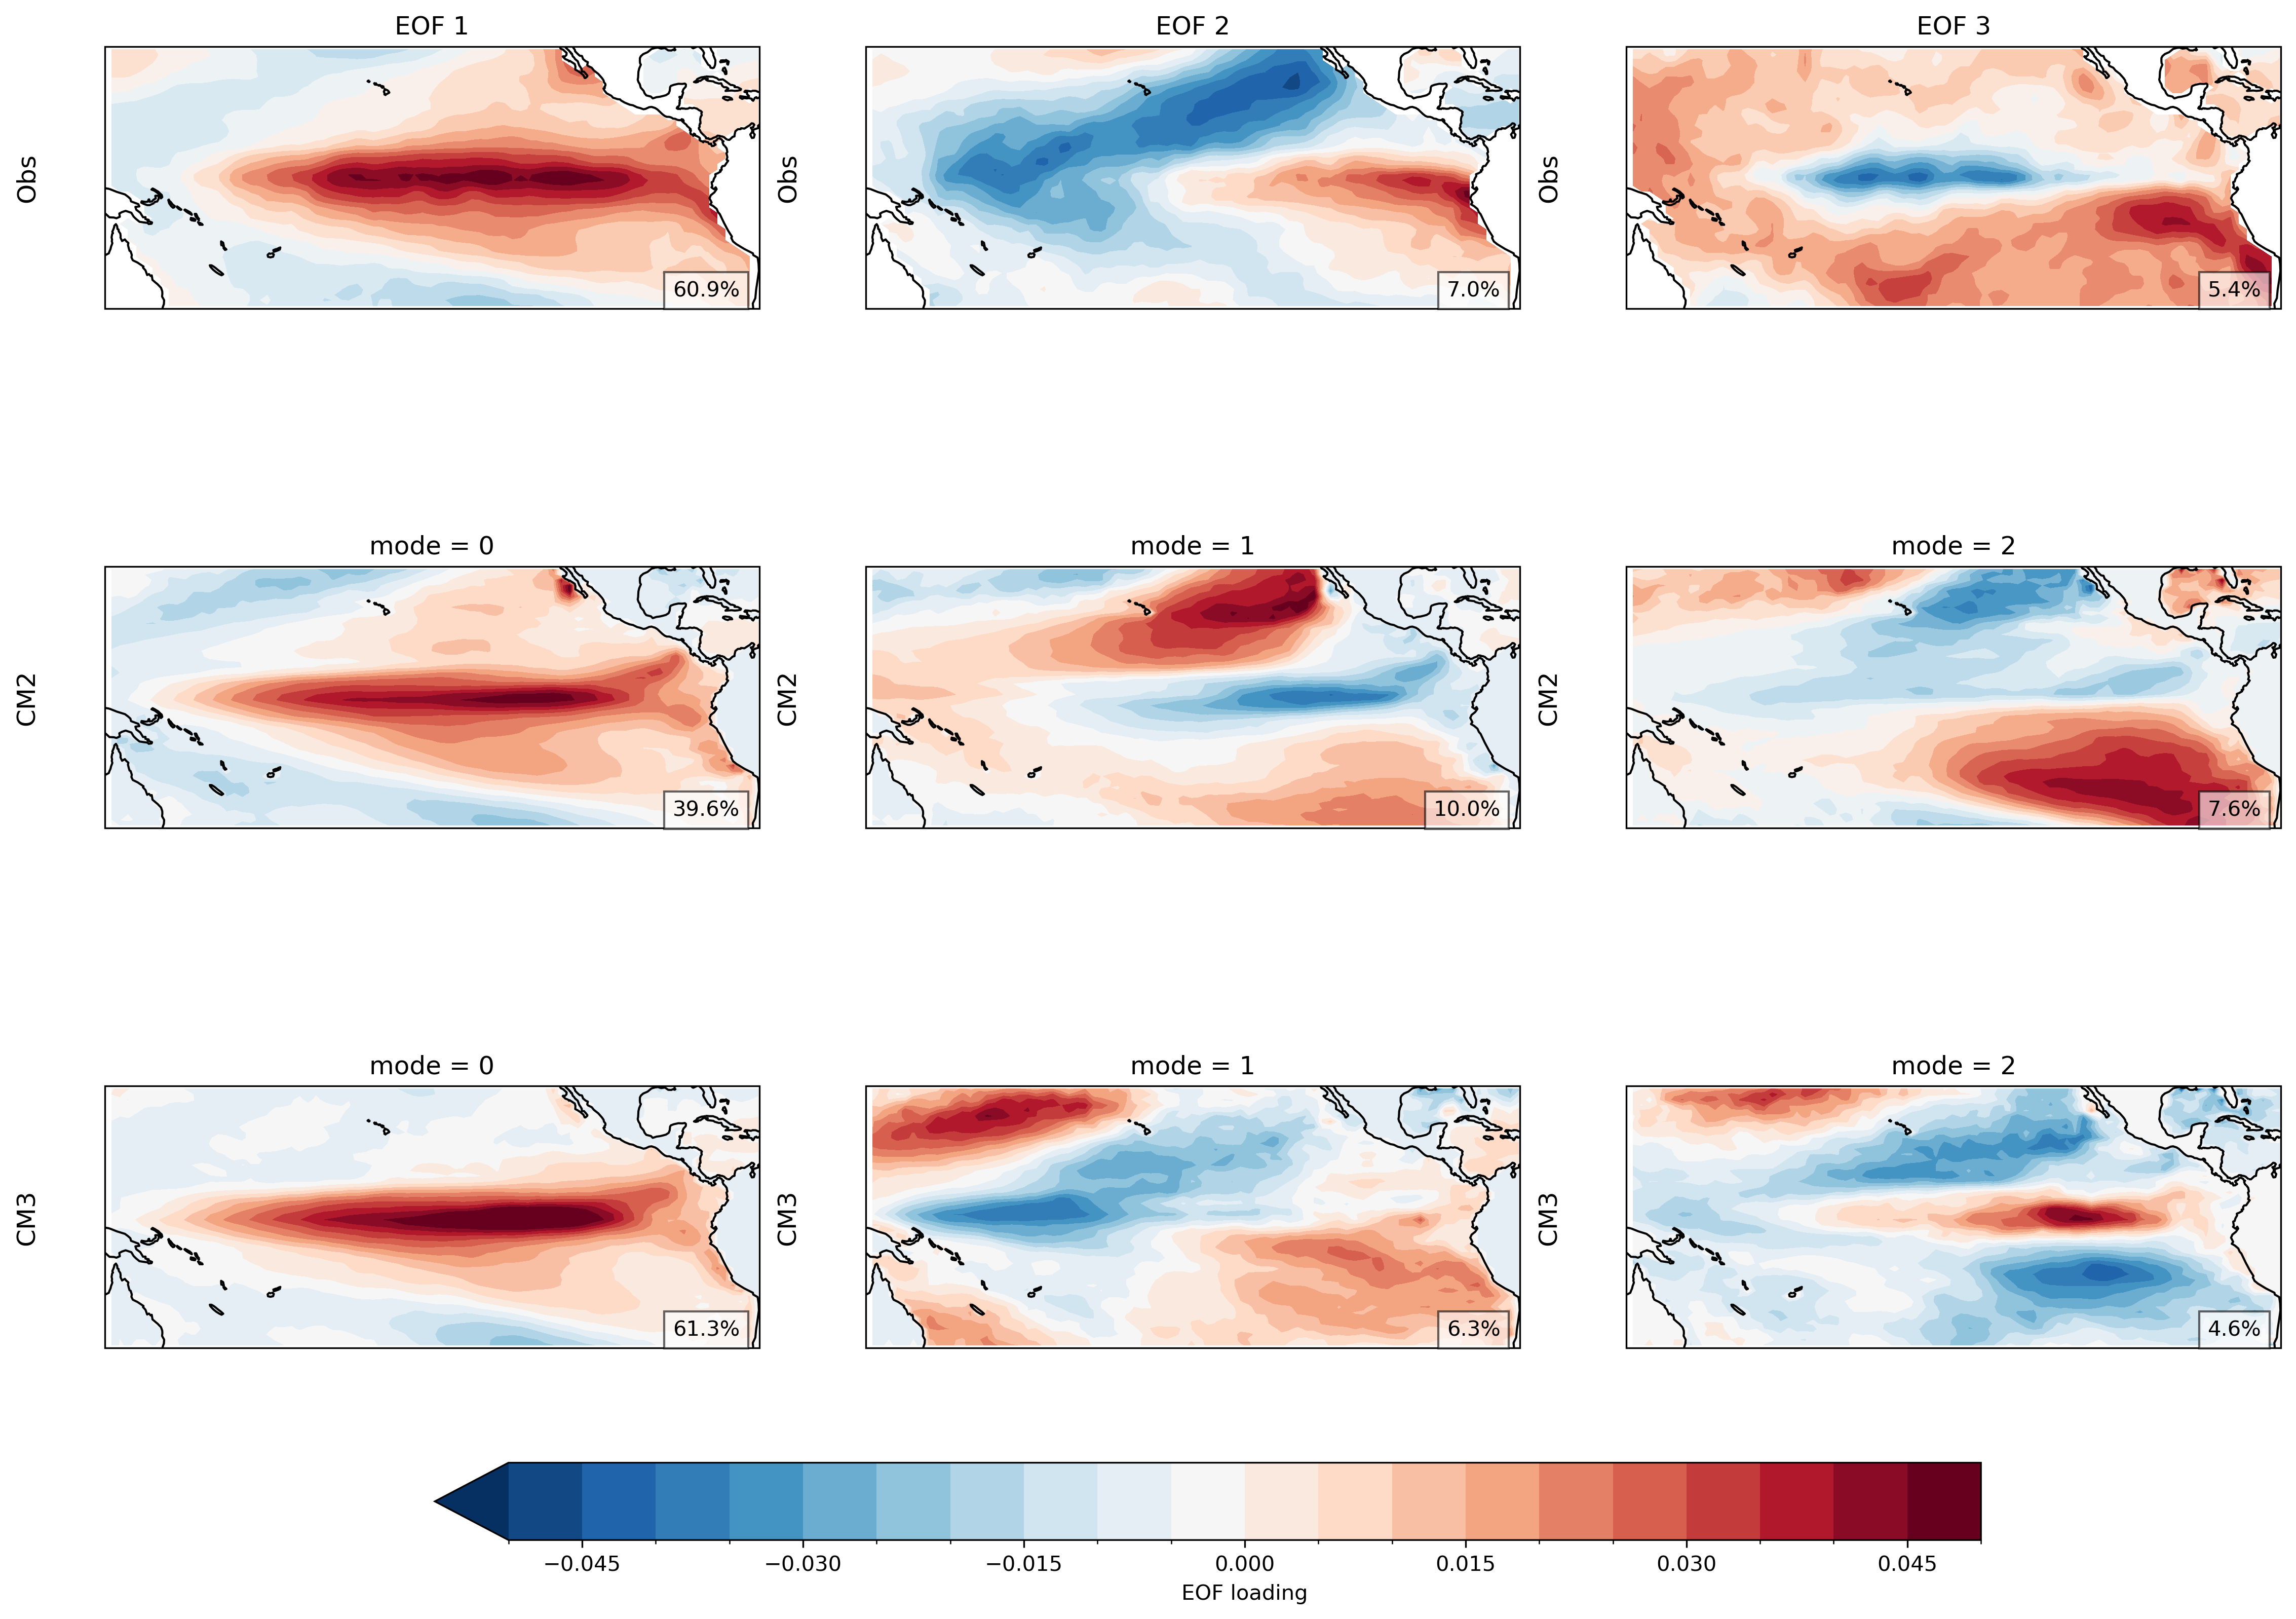

<Figure size 1920x1440 with 0 Axes>

In [61]:
import cartopy.crs as ccrs
proj = ccrs.PlateCarree(central_longitude=180)


# Figure
fig, axes = plt.subplots(
    nrows=3, ncols=3,
    figsize=(15, 12),
    subplot_kw={"projection": proj},
    constrained_layout=True
)
datasets=['Obs','CM2',label]
eofs_list = [obs_eof, -cm2_eof, -exp_eof]
vars_list = [obs_var, cm2_var, exp_var]
n_eofs=3
M=0.05
m=-0.05
cmap='RdBu_r'

for i, (name, eofs, var) in enumerate(zip(datasets, eofs_list, vars_list)):
    for j in range(n_eofs):
        ax = axes[i, j]

        # contourf plot with transform to PlateCarree
        pcm = eofs.sel(mode=j).plot.contourf(
            ax=ax,
            levels=21,
            transform=ccrs.PlateCarree(),vmin=m,vmax=M,
            add_colorbar=False,cmap=cmap     )

        # coastlines
        ax.coastlines()

        # titles & labels
        if i == 0:
            ax.set_title(f"EOF {j+1}", fontsize=12)

        if j == 0:
            ax.set_ylabel(name, rotation=0, labelpad=35, fontsize=12)

        # variance explained
        ax.text(
            0.97, 0.03,
            f"{var[j]:.1f}%",
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.6)
        )
        ax.text(
        -0.1, 0.5, name,
        rotation=90,
        transform=ax.transAxes,
        va='center', ha='right', fontsize=12
        )

        ax.set_extent([140, 290, -30, 30], crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True, degree_symbol=''))
        ax.yaxis.set_major_formatter(LatitudeFormatter(degree_symbol=''))
        ax.set_xlabel('')
        ax.tick_params(axis='both', labelsize=12) 
    
# shared colorbar
cbar = fig.colorbar(
    pcm, ax=axes,
    orientation='horizontal',
    fraction=0.05,
    pad=0.07,
)
cbar.set_label('EOF loading')
plt.show()
plt.savefig(plotfolder+"ts_djf_eof.png", bbox_inches="tight", dpi=750)

In [62]:
#now calculate for IPO

exp_lowpass = lowpass_butterworth_xr(exp_ts_monanom.sel(lat=slice(-30,30),lon=slice(140,290)), cutoff_yrs=13)
cm2_lowpass = lowpass_butterworth_xr(cm2_ts_monanom.sel(lat=slice(-30,30),lon=slice(140,290)), cutoff_yrs=13)
obs_lowpass = lowpass_butterworth_xr(obs_ts_monanom.sel(lat=slice(-30,30),lon=slice(140,290)), cutoff_yrs=13)



In [63]:
masked_exp_lp = exp_lowpass * mask_binary
masked_cm2_lp = cm2_lowpass * mask_binary

masked_exp_lp = masked_exp_lp.transpose("time", "lat", "lon")
masked_cm2_lp = masked_cm2_lp.transpose("time", "lat", "lon")
obs_lowpass = obs_lowpass.transpose("time", "lat", "lon")


In [72]:
from eofs.xarray import Eof

exp_solver_lp = Eof(masked_exp_lp.sel(lat=slice(-30,30),lon=slice(140,290)) * weights_model)
exp_eof_lp = exp_solver_lp.eofs(neofs=3)
exp_var_lp  = exp_solver_lp.varianceFraction().values[:3] * 100

cm2_solver_lp = Eof(masked_cm2_lp.sel(lat=slice(-30,30),lon=slice(140,290))  * weights_model)
cm2_eof_lp = cm2_solver_lp.eofs(neofs=3)
cm2_eof_lp[0] = -cm2_eof_lp[0]

cm2_var_lp  = cm2_solver_lp.varianceFraction().values[:3] * 100

obs_solver_lp = Eof(obs_lowpass.sel(lat=slice(-30,30),lon=slice(140,290)) * weights_obs)
obs_eof_lp= obs_solver_lp.eofs(neofs=3)
obs_var_lp  = obs_solver_lp.varianceFraction().values[:3] * 100

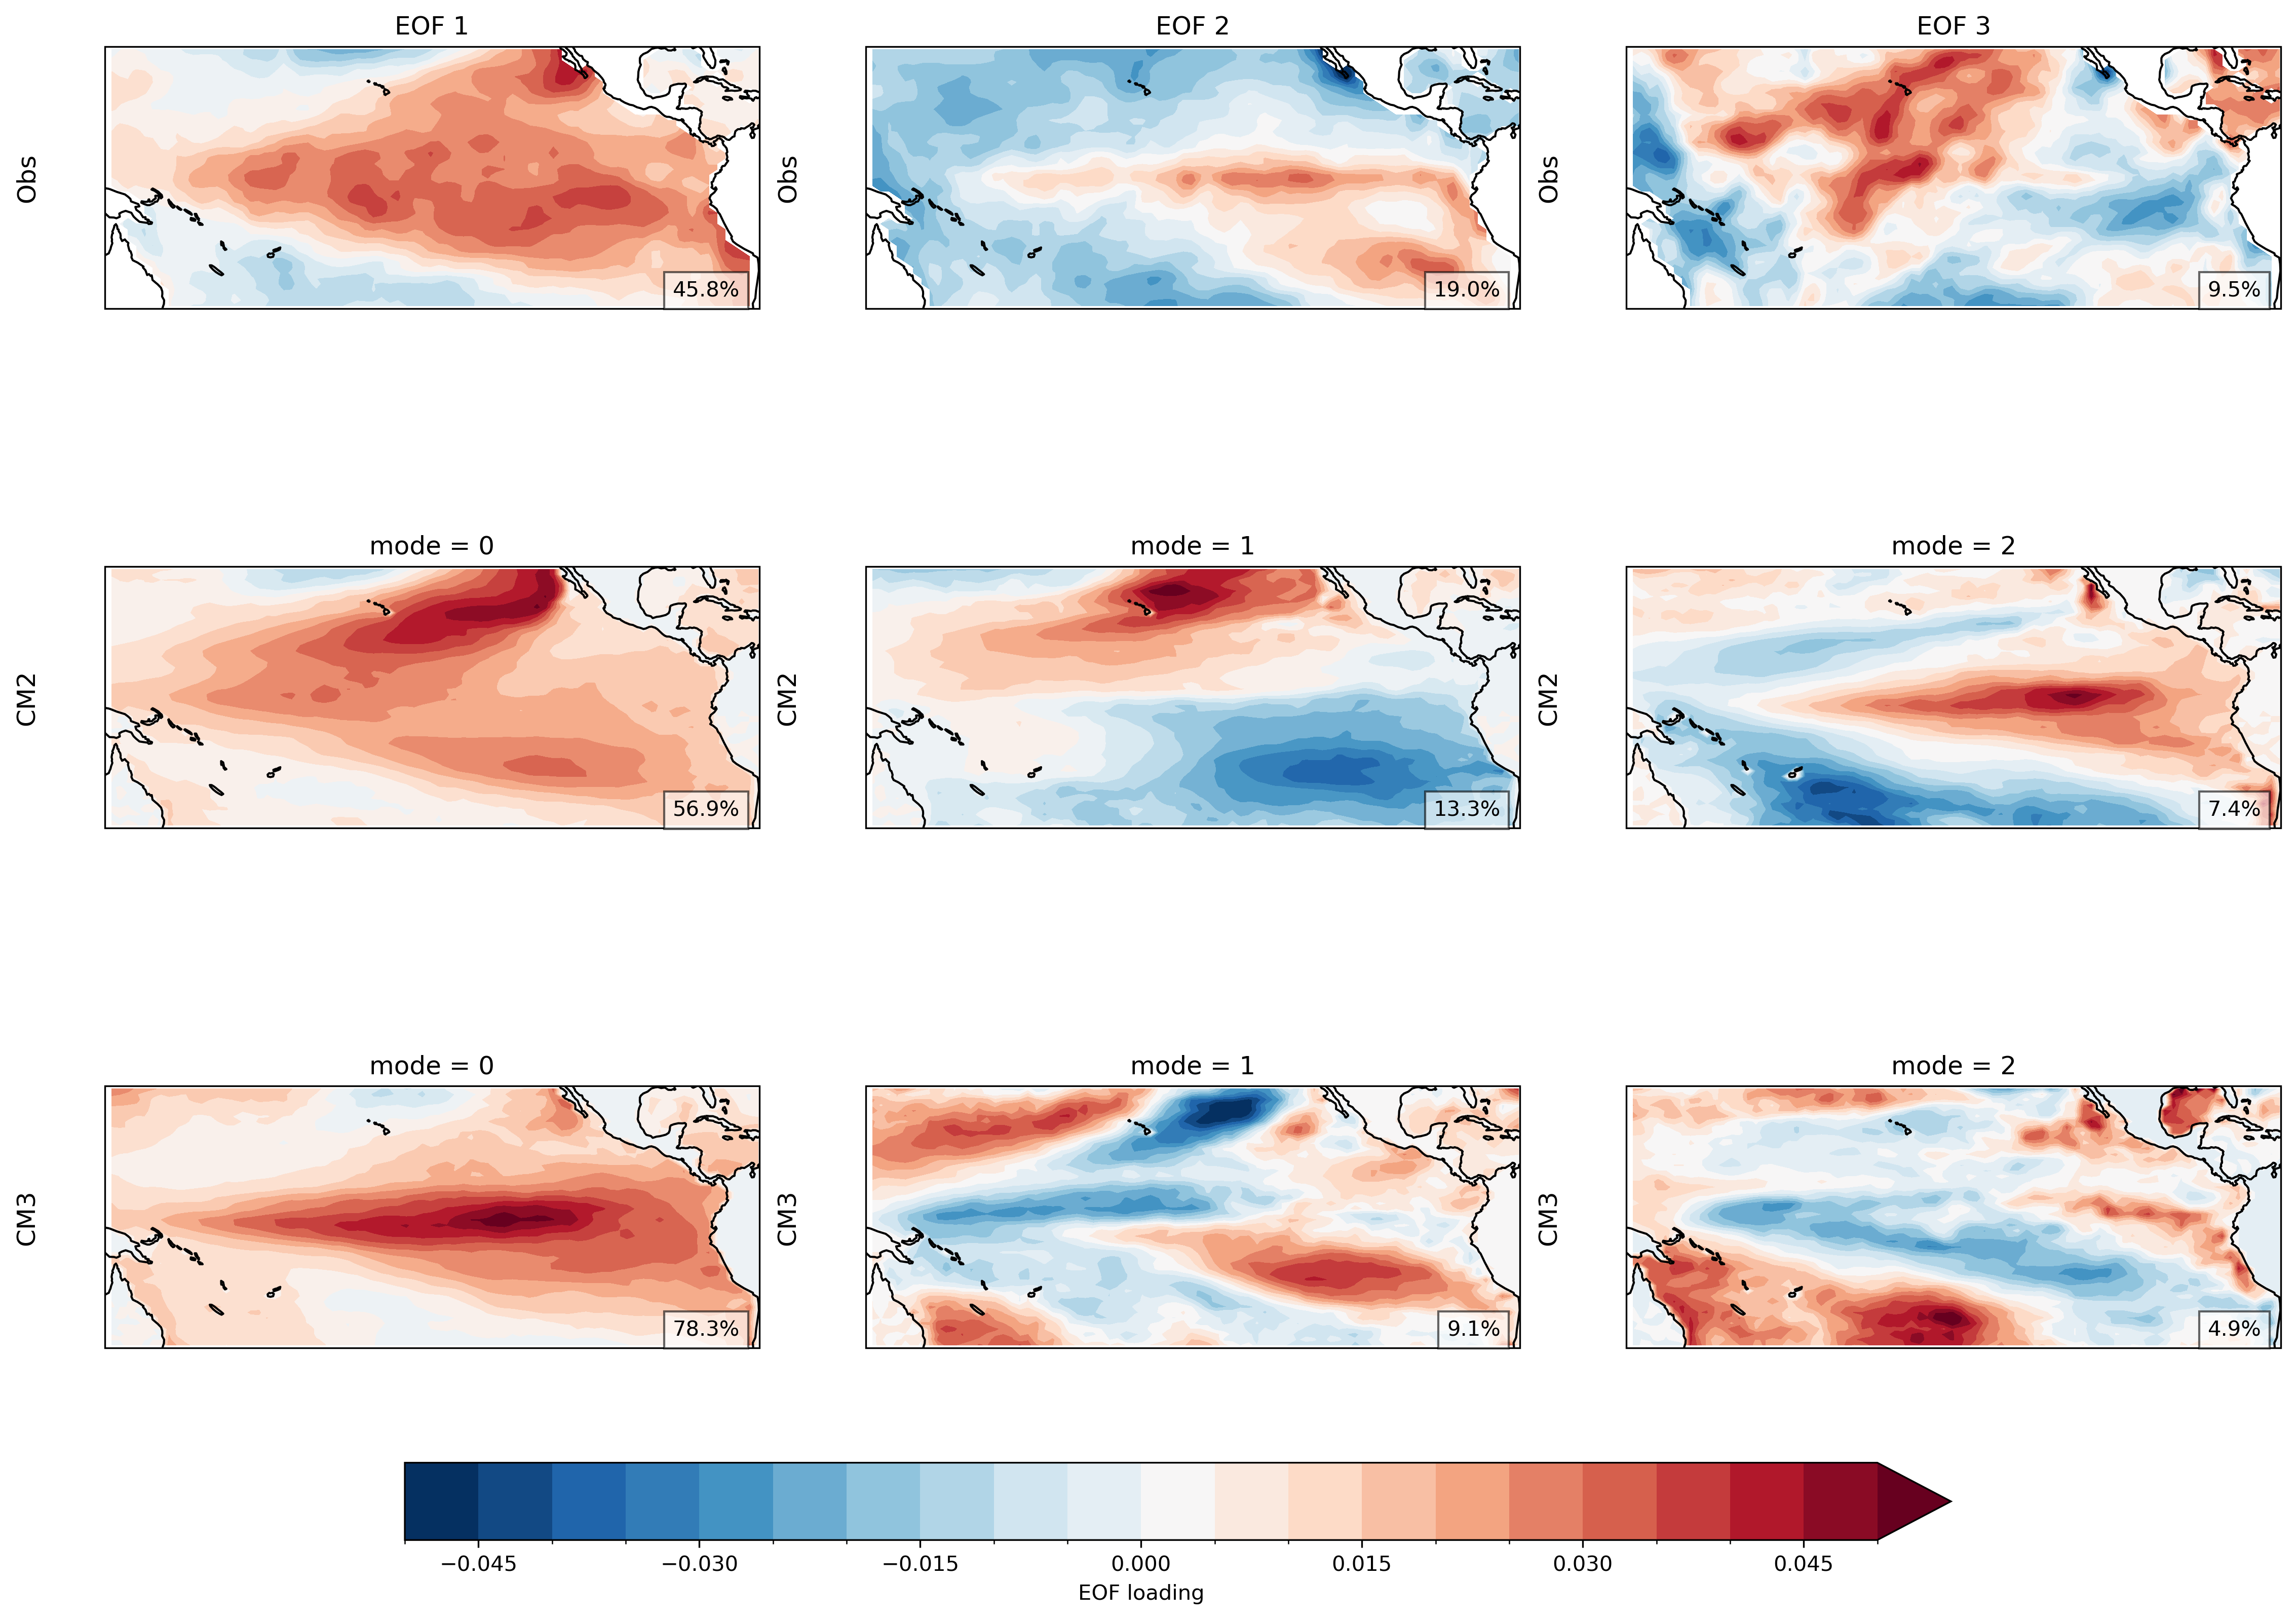

<Figure size 1920x1440 with 0 Axes>

In [73]:

# Figure
fig, axes = plt.subplots(
    nrows=3, ncols=3,
    figsize=(15, 12),
    subplot_kw={"projection": proj},
    constrained_layout=True
)
datasets=['Obs','CM2',label]
eofs_list = [obs_eof_lp, cm2_eof_lp, -exp_eof_lp]
vars_list = [obs_var_lp, cm2_var_lp, exp_var_lp]
n_eofs=3
M=0.05
m=-0.05
cmap='RdBu_r'

for i, (name, eofs, var) in enumerate(zip(datasets, eofs_list, vars_list)):
    for j in range(n_eofs):
        ax = axes[i, j]

        # contourf plot with transform to PlateCarree
        pcm = eofs.sel(mode=j).plot.contourf(
            ax=ax,
            levels=21,
            transform=ccrs.PlateCarree(),vmin=m,vmax=M,
            add_colorbar=False,cmap=cmap     )

        # coastlines
        ax.coastlines()

        # titles & labels
        if i == 0:
            ax.set_title(f"EOF {j+1}", fontsize=12)

        if j == 0:
            ax.set_ylabel(name, rotation=0, labelpad=35, fontsize=12)

        # variance explained
        ax.text(
            0.97, 0.03,
            f"{var[j]:.1f}%",
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.6)
        )
        ax.text(
        -0.1, 0.5, name,
        rotation=90,
        transform=ax.transAxes,
        va='center', ha='right', fontsize=12
        )

        ax.set_extent([140, 290, -30, 30], crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True, degree_symbol=''))
        ax.yaxis.set_major_formatter(LatitudeFormatter(degree_symbol=''))
        ax.set_xlabel('')
        ax.tick_params(axis='both', labelsize=12) 
    
# shared colorbar
cbar = fig.colorbar(
    pcm, ax=axes,
    orientation='horizontal',
    fraction=0.05,
    pad=0.07,
)
cbar.set_label('EOF loading')
plt.show()
plt.savefig(plotfolder+"ts_13y_lp_eof", bbox_inches="tight", dpi=750)